### Model certainty on COMPAS

We compare **logistic regression** and a **random forest** on the COMPAS recidivism task, with calibration analysed separately for **Black** and **White** defendants.

For each confidence bin, overlaid bars show whether the model's **confidence** or **accuracy** is higher. The **calibration gap** is confidence minus accuracy.

We also plot **ROC curves**, report **equalized odds difference**, and compute **confidence-based ECE**, **Brier score**, and **log loss** (lower is better for ECE, Brier score, log loss, and equalized odds difference).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from fairlearn.metrics import equalized_odds_difference
from sklearn.metrics import accuracy_score, auc, brier_score_loss, log_loss, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df = pd.read_csv("../data/compas_clean.csv")
df = df[df["race"].isin(["African-American", "Caucasian"])].copy()

features = ["sex", "age", "priors_count", "c_charge_degree"]
X = df[features]
y = df["two_year_recid"].astype(int)

train_idx, test_idx = train_test_split(
    df.index, test_size=0.25, random_state=42, stratify=y
)
X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]
race_test = df.loc[test_idx, "race"]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in features if c not in cat_cols]


def make_pipeline(estimator, scale_numeric):
    num_transformer = StandardScaler() if scale_numeric else "passthrough"
    return Pipeline(
        [
            (
                "prep",
                ColumnTransformer(
                    [
                        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
                        ("num", num_transformer, num_cols),
                    ]
                ),
            ),
            ("clf", estimator),
        ]
    )


MODEL_SPECS = {
    "Logistic regression": make_pipeline(LogisticRegression(max_iter=1000), scale_numeric=True),
    "Random forest": make_pipeline(
        RandomForestClassifier(n_estimators=200, random_state=42),
        scale_numeric=False,
    ),
}

MODELS = {}
for name, pipeline in MODEL_SPECS.items():
    pipeline.fit(X_train, y_train)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = pipeline.predict(X_test)
    MODELS[name] = {"y_proba": y_proba, "y_pred": y_pred}
    print(f"{name} test accuracy: {accuracy_score(y_test, y_pred):.3f}")


Logistic regression test accuracy: 0.661
Random forest test accuracy: 0.623


,model,group,accuracy,ECE,Brier score,log loss
0,Logistic regression,Overall,0.661,0.0373,0.2141,0.6184
1,Logistic regression,Black (African-American),0.650,0.0402,0.2194,0.6307
2,Logistic regression,White (Caucasian),0.676,0.0372,0.2065,0.6003
3,Random forest,Overall,0.623,0.1279,0.2532,1.3294
4,Random forest,Black (African-American),0.614,0.1305,0.2563,1.1036
5,Random forest,White (Caucasian),0.636,0.1269,0.2487,1.6611


,model,equalized odds difference
0,Logistic regression,0.2380
1,Random forest,0.1592


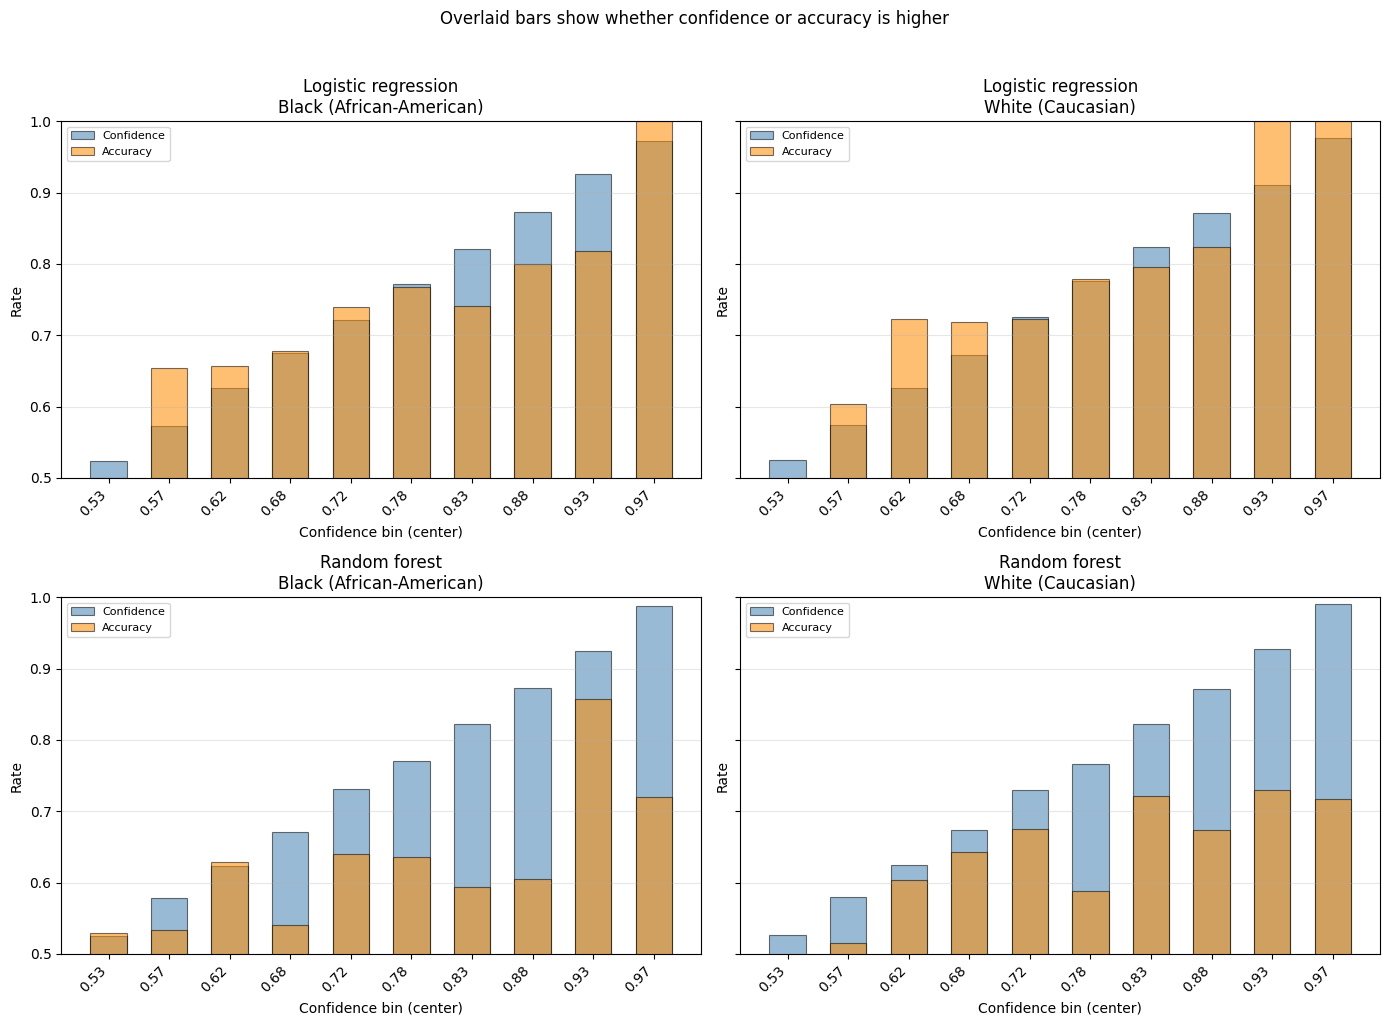

In [3]:
RACE_GROUPS = {
    "Black (African-American)": "African-American",
    "White (Caucasian)": "Caucasian",
}
N_BINS = 10
line_styles = {
    "Black (African-American)": {"color": "steelblue", "marker": "o"},
    "White (Caucasian)": {"color": "darkorange", "marker": "s"},
}


def confidence_scores(y_proba):
    y_pred = (y_proba >= 0.5).astype(int)
    return np.where(y_pred == 1, y_proba, 1 - y_proba), y_pred


def reliability_by_score(y_true, y_proba, n_bins=N_BINS):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    bin_edges = np.linspace(0, 1, n_bins + 1)

    mean_scores, frac_positive, counts = [], [], []
    for low, high in zip(bin_edges[:-1], bin_edges[1:]):
        if high == bin_edges[-1]:
            mask = (y_proba >= low) & (y_proba <= high)
        else:
            mask = (y_proba >= low) & (y_proba < high)
        if mask.sum() == 0:
            continue
        mean_scores.append(y_proba[mask].mean())
        frac_positive.append(y_true[mask].mean())
        counts.append(mask.sum())

    return (
        np.array(mean_scores),
        np.array(frac_positive),
        np.array(counts),
    )


def expected_calibration_error(y_true, y_proba, n_bins=N_BINS):
    y_true = np.asarray(y_true)
    confidence, y_pred = confidence_scores(y_proba)
    bin_edges = np.linspace(0.5, 1.0, n_bins + 1)

    ece = 0.0
    n = len(y_true)
    for low, high in zip(bin_edges[:-1], bin_edges[1:]):
        if high == bin_edges[-1]:
            mask = (confidence >= low) & (confidence <= high)
        else:
            mask = (confidence >= low) & (confidence < high)
        if mask.sum() == 0:
            continue
        bin_confidence = confidence[mask].mean()
        bin_accuracy = (y_pred[mask] == y_true[mask]).mean()
        ece += (mask.sum() / n) * abs(bin_confidence - bin_accuracy)
    return ece


def calibration_by_confidence(y_true, y_proba, n_bins=N_BINS):
    confidence, y_pred = confidence_scores(y_proba)
    bin_edges = np.linspace(0.5, 1.0, n_bins + 1)

    centers, mean_confidence, accuracies, counts = [], [], [], []
    for low, high in zip(bin_edges[:-1], bin_edges[1:]):
        if high == bin_edges[-1]:
            mask = (confidence >= low) & (confidence <= high)
        else:
            mask = (confidence >= low) & (confidence < high)
        if mask.sum() == 0:
            continue
        centers.append((low + high) / 2)
        mean_confidence.append(confidence[mask].mean())
        accuracies.append((y_pred[mask] == y_true[mask]).mean())
        counts.append(mask.sum())

    centers = np.array(centers)
    mean_confidence = np.array(mean_confidence)
    accuracies = np.array(accuracies)
    gaps = mean_confidence - accuracies
    return centers, mean_confidence, accuracies, gaps, np.array(counts)


def plot_calibration_bars(ax, y_true, y_proba, title):
    centers, mean_confidence, accuracies, gaps, counts = calibration_by_confidence(
        y_true, y_proba
    )

    if len(centers) == 0:
        ax.set_title(f"{title}\n(no predictions in bins)")
        ax.set_ylim(0.5, 1.0)
        return centers, gaps

    x = np.arange(len(centers))
    width = 0.6
    ax.bar(
        x,
        mean_confidence,
        width,
        label="Confidence",
        color="steelblue",
        alpha=0.55,
        edgecolor="black",
        linewidth=0.8,
    )
    ax.bar(
        x,
        accuracies,
        width,
        label="Accuracy",
        color="darkorange",
        alpha=0.55,
        edgecolor="black",
        linewidth=0.8,
    )

    ax.set_title(title)
    ax.set_xlabel("Confidence bin (center)")
    ax.set_ylabel("Rate")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{c:.2f}" for c in centers], rotation=45, ha="right")
    ax.set_ylim(0.5, 1.0)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    return centers, gaps


race_calibration = {model_name: {} for model_name in MODELS}
race_reliability = {model_name: {} for model_name in MODELS}
metric_rows = []

for model_name, outputs in MODELS.items():
    metric_rows.append(
        {
            "model": model_name,
            "group": "Overall",
            "accuracy": accuracy_score(y_test, outputs["y_pred"]),
            "ECE": expected_calibration_error(y_test, outputs["y_proba"]),
            "Brier score": brier_score_loss(y_test, outputs["y_proba"]),
            "log loss": log_loss(y_test, outputs["y_proba"]),
        }
    )
    for race_label, race_value in RACE_GROUPS.items():
        race_mask = race_test == race_value
        y_true_group = y_test.loc[race_mask]
        y_proba_group = outputs["y_proba"][race_mask.to_numpy()]
        y_pred_group = outputs["y_pred"][race_mask.to_numpy()]
        race_reliability[model_name][race_label] = reliability_by_score(
            y_true_group, y_proba_group
        )
        metric_rows.append(
            {
                "model": model_name,
                "group": race_label,
                "accuracy": accuracy_score(y_true_group, y_pred_group),
                "ECE": expected_calibration_error(y_true_group, y_proba_group),
                "Brier score": brier_score_loss(y_true_group, y_proba_group),
                "log loss": log_loss(y_true_group, y_proba_group),
            }
        )

metrics_table = pd.DataFrame(metric_rows)
display(
    metrics_table.style.format(
        {
            "accuracy": "{:.3f}",
            "ECE": "{:.4f}",
            "Brier score": "{:.4f}",
            "log loss": "{:.4f}",
        }
    )
)

fairness_rows = []
for model_name, outputs in MODELS.items():
    fairness_rows.append(
        {
            "model": model_name,
            "equalized odds difference": equalized_odds_difference(
                y_test, outputs["y_pred"], sensitive_features=race_test
            ),
        }
    )
fairness_table = pd.DataFrame(fairness_rows)
display(
    fairness_table.style.format({"equalized odds difference": "{:.4f}"})
)

fig, axes = plt.subplots(len(MODELS), 2, figsize=(14, 5 * len(MODELS)), sharey=True)

for row, (model_name, outputs) in enumerate(MODELS.items()):
    for col, (race_label, race_value) in enumerate(RACE_GROUPS.items()):
        race_mask = race_test == race_value
        y_true_group = y_test.loc[race_mask]
        y_proba_group = outputs["y_proba"][race_mask.to_numpy()]

        centers, gaps = plot_calibration_bars(
            axes[row, col],
            y_true_group,
            y_proba_group,
            f"{model_name}\n{race_label}",
        )
        race_calibration[model_name][race_label] = (centers, gaps)

fig.suptitle(
    "Overlaid bars show whether confidence or accuracy is higher",
    y=1.02,
)
plt.tight_layout()
plt.show()


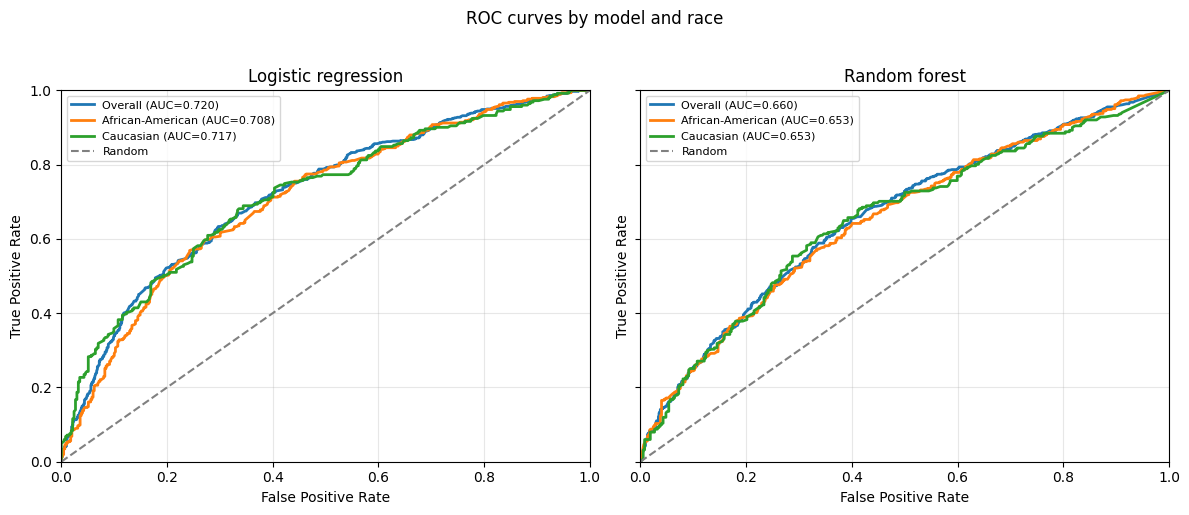

In [4]:
def plot_roc_curves(ax, y_true, y_score, groups, title):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ax.plot(fpr, tpr, linewidth=2, label=f"Overall (AUC={auc(fpr, tpr):.3f})")

    for group in sorted(groups.unique()):
        mask = (groups == group).to_numpy()
        fpr_g, tpr_g, _ = roc_curve(y_true[mask], y_score[mask])
        ax.plot(
            fpr_g,
            tpr_g,
            linewidth=2,
            label=f"{group} (AUC={auc(fpr_g, tpr_g):.3f})",
        )

    ax.plot([0, 1], [0, 1], "--", color="gray", label="Random")
    ax.set_title(title)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 5), sharey=True)

if len(MODELS) == 1:
    axes = [axes]

for ax, (model_name, outputs) in zip(axes, MODELS.items()):
    plot_roc_curves(
        ax,
        y_test.to_numpy(),
        outputs["y_proba"],
        race_test,
        model_name,
    )

fig.suptitle("ROC curves by model and race", y=1.02)
plt.tight_layout()
plt.show()

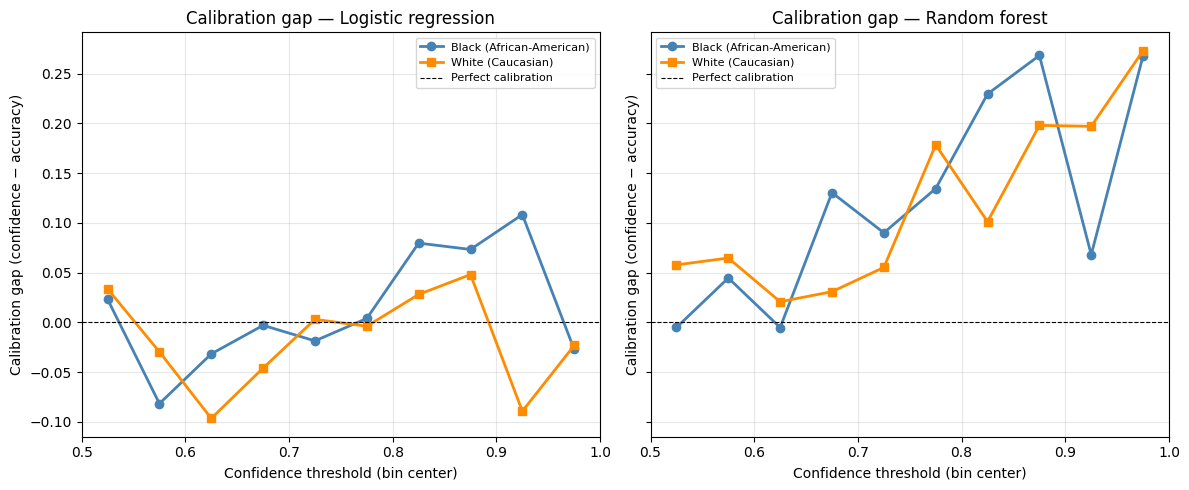

In [5]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 5), sharey=True)

if len(MODELS) == 1:
    axes = [axes]

for ax, model_name in zip(axes, MODELS):
    for race_label, (centers, gaps) in race_calibration[model_name].items():
        if len(centers) == 0:
            continue
        style = line_styles[race_label]
        ax.plot(
            centers,
            gaps,
            linewidth=2,
            label=race_label,
            color=style["color"],
            marker=style["marker"],
        )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", label="Perfect calibration")
    ax.set_xlabel("Confidence threshold (bin center)")
    ax.set_ylabel("Calibration gap (confidence − accuracy)")
    ax.set_title(f"Calibration gap — {model_name}")
    ax.set_xlim(0.5, 1.0)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


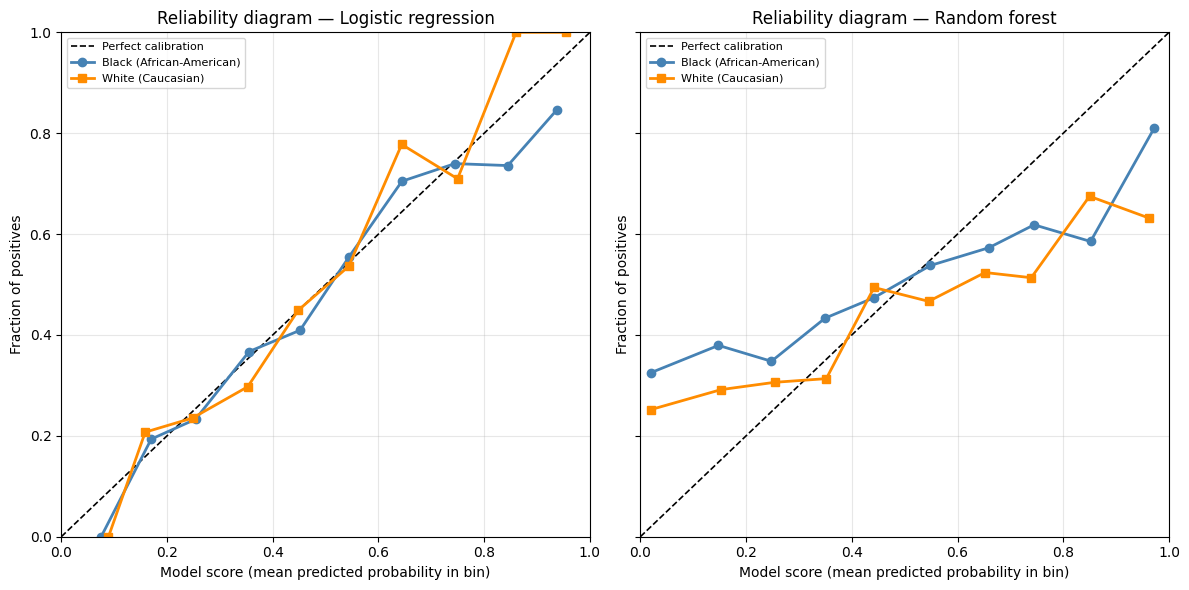

In [6]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 6), sharey=True)

if len(MODELS) == 1:
    axes = [axes]

for ax, model_name in zip(axes, MODELS):
    ax.plot([0, 1], [0, 1], "--", color="black", linewidth=1.2, label="Perfect calibration")

    for race_label, (mean_scores, frac_positive, counts) in race_reliability[model_name].items():
        if len(mean_scores) == 0:
            continue
        style = line_styles[race_label]
        ax.plot(
            mean_scores,
            frac_positive,
            linewidth=2,
            label=race_label,
            color=style["color"],
            marker=style["marker"],
        )

    ax.set_xlabel("Model score (mean predicted probability in bin)")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(f"Reliability diagram — {model_name}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


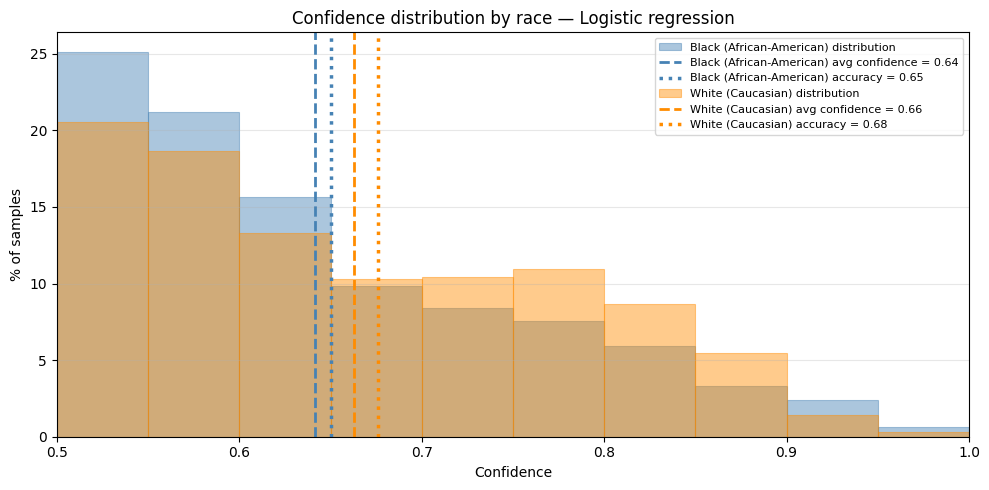

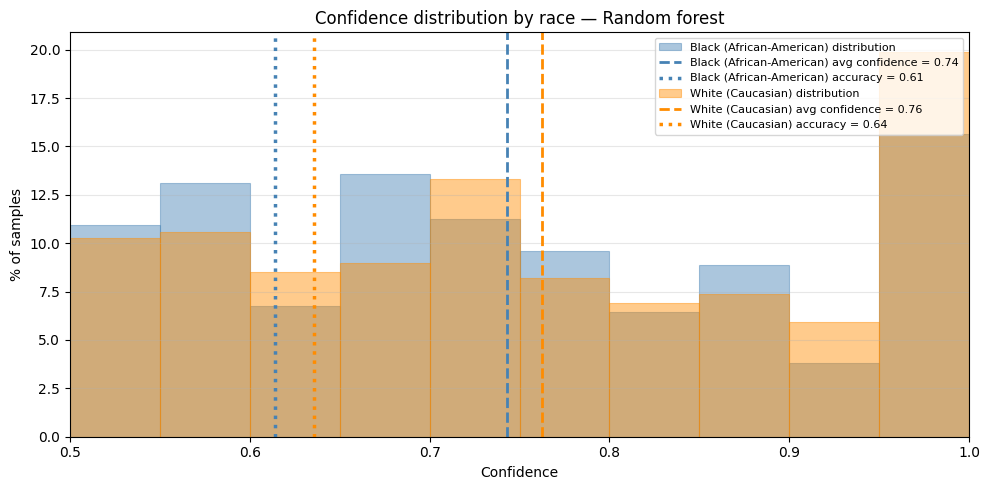

In [7]:
for model_name, outputs in MODELS.items():
    fig, ax = plt.subplots(figsize=(10, 5))
    hist_bins = np.linspace(0.5, 1.0, N_BINS + 1)

    for race_label, race_value in RACE_GROUPS.items():
        race_mask = race_test == race_value
        y_true_group = y_test.loc[race_mask].to_numpy()
        y_proba_group = outputs["y_proba"][race_mask.to_numpy()]

        confidence, y_pred = confidence_scores(y_proba_group)
        pct_weights = np.ones_like(confidence) / len(confidence) * 100
        color = line_styles[race_label]["color"]

        ax.hist(
            confidence,
            bins=hist_bins,
            weights=pct_weights,
            color=color,
            edgecolor=color,
            linewidth=0.8,
            alpha=0.45,
            label=f"{race_label} distribution",
        )

        avg_confidence = confidence.mean()
        accuracy = (y_pred == y_true_group).mean()

        ax.axvline(
            avg_confidence,
            color=color,
            linestyle="--",
            linewidth=2,
            label=f"{race_label} avg confidence = {avg_confidence:.2f}",
        )
        ax.axvline(
            accuracy,
            color=color,
            linestyle=":",
            linewidth=2.5,
            label=f"{race_label} accuracy = {accuracy:.2f}",
        )

    ax.set_xlabel("Confidence")
    ax.set_ylabel("% of samples")
    ax.set_xlim(0.5, 1.0)
    ax.set_title(f"Confidence distribution by race — {model_name}")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


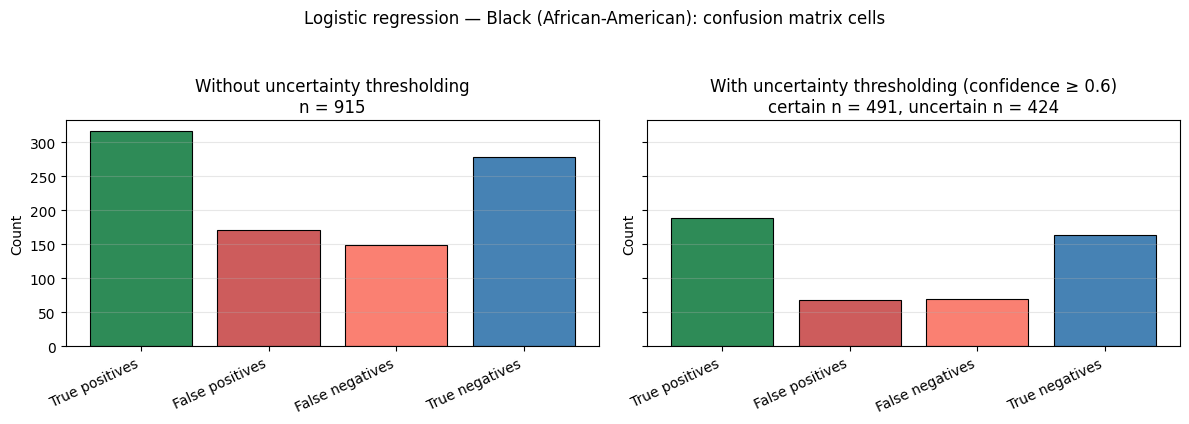

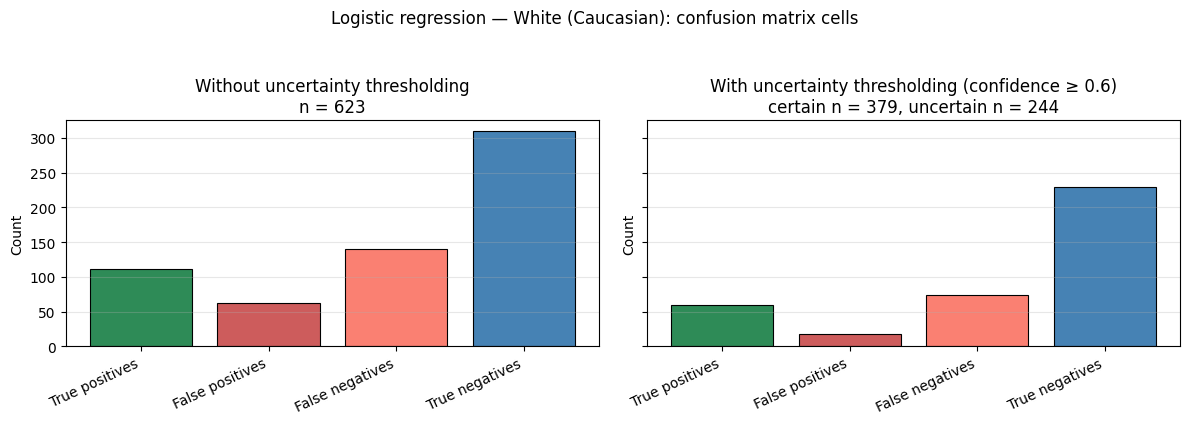

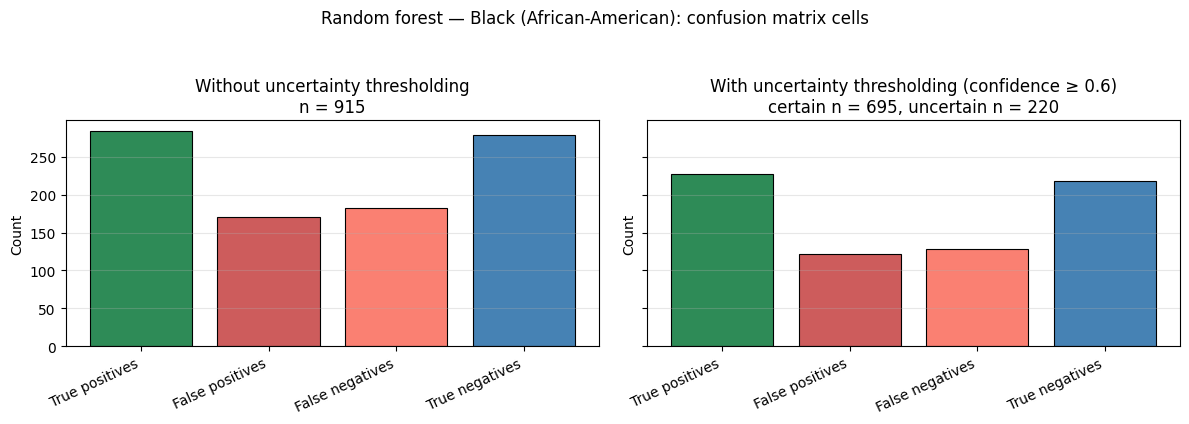

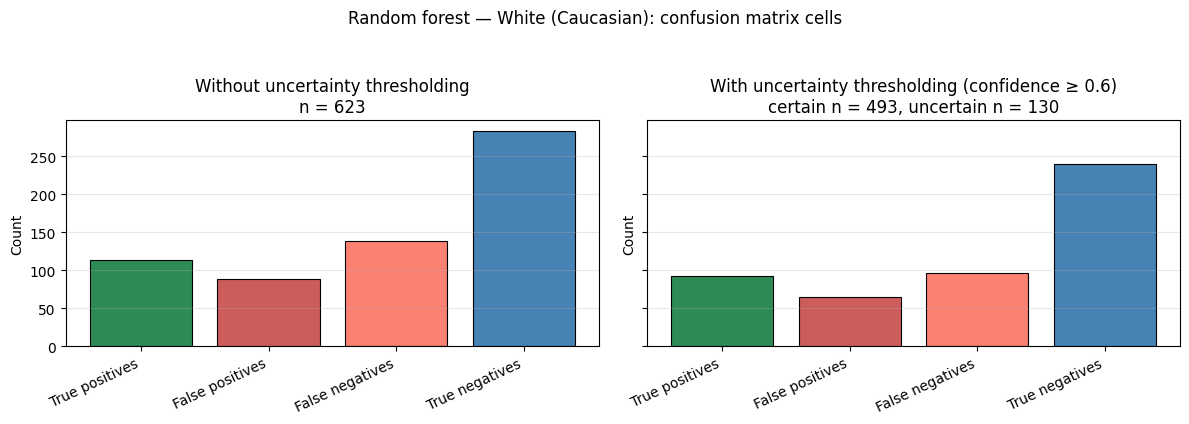

In [8]:
from sklearn.metrics import confusion_matrix

CERTAINTY_THRESHOLD = 0.6
CM_LABELS = ["True positives", "False positives", "False negatives", "True negatives"]
CM_COLORS = ["seagreen", "indianred", "salmon", "steelblue"]


def confusion_counts(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "True positives": tp,
        "False positives": fp,
        "False negatives": fn,
        "True negatives": tn,
    }


def plot_confusion_bars(ax, counts, title, n_total, n_used=None):
    values = [counts[label] for label in CM_LABELS]
    x = np.arange(len(CM_LABELS))

    ax.bar(x, values, color=CM_COLORS, edgecolor="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(CM_LABELS, rotation=25, ha="right")
    ax.set_ylabel("Count")

    if n_used is None:
        subtitle = f"n = {n_total}"
    else:
        n_abstained = n_total - n_used
        subtitle = f"certain n = {n_used}, uncertain n = {n_abstained}"

    ax.set_title(f"{title}\n{subtitle}")
    ax.grid(axis="y", alpha=0.3)


for model_name, outputs in MODELS.items():
    for race_label, race_value in RACE_GROUPS.items():
        race_mask = race_test == race_value
        y_true_group = y_test.loc[race_mask].to_numpy()
        y_proba_group = outputs["y_proba"][race_mask.to_numpy()]
        y_pred_group = outputs["y_pred"][race_mask.to_numpy()]
        n_total = len(y_true_group)

        counts_without = confusion_counts(y_true_group, y_pred_group)

        confidence, y_pred = confidence_scores(y_proba_group)
        certain_mask = confidence >= CERTAINTY_THRESHOLD
        counts_with = confusion_counts(
            y_true_group[certain_mask],
            y_pred[certain_mask],
        )

        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

        plot_confusion_bars(
            axes[0],
            counts_without,
            "Without uncertainty thresholding",
            n_total,
        )
        plot_confusion_bars(
            axes[1],
            counts_with,
            f"With uncertainty thresholding (confidence ≥ {CERTAINTY_THRESHOLD})",
            n_total,
            n_used=certain_mask.sum(),
        )

        fig.suptitle(
            f"{model_name} — {race_label}: confusion matrix cells",
            y=1.05,
        )
        plt.tight_layout()
        plt.show()
